In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("C:/Users/avnis/Downloads/archive/shoes_sales_dataset.csv")

# Date handling
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Drop useless columns
df.drop(['Sale_ID','Date'], axis=1, inplace=True)

# Encode categorical
le = LabelEncoder()
for col in ['Brand','Shoe_Type','Color','Country','Sales_Channel']:
    df[col] = le.fit_transform(df[col])

### Revenue Prediction (Regression)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df.drop('Revenue_USD', axis=1)
y = df['Revenue_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Sample Prediction:", y_pred[:5])

R2 Score: 0.8853898440401354
Sample Prediction: [1475.80338098  328.24418114  653.52178541 1541.77588236 2635.32234835]


### Sales Category Classification

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create category
df['Sales_Category'] = df['Units_Sold'].apply(
    lambda x: 1 if x > df['Units_Sold'].mean() else 0
)

X = df.drop('Sales_Category', axis=1)
y = df['Sales_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Predictions:", y_pred[:5])

Accuracy: 1.0
Predictions: [1 1 0 0 0]


### Price vs Sales Analysis

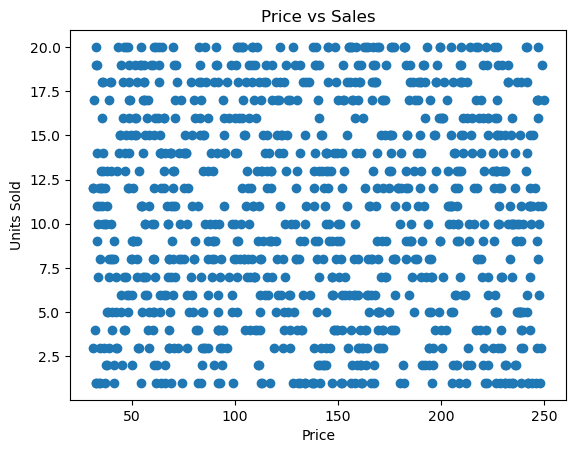

Correlation: -0.015692590661243455


In [9]:
plt.scatter(df['Price_USD'], df['Units_Sold'])
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Sales")

# Save graph
plt.savefig("price_vs_sales.png")

plt.show()

print("Correlation:", df['Price_USD'].corr(df['Units_Sold']))

### Sales Channel Performance

===== CHANNEL PERFORMANCE =====
Sales_Channel
0    479288.58
1    467772.32
2    506125.13
Name: Revenue_USD, dtype: float64


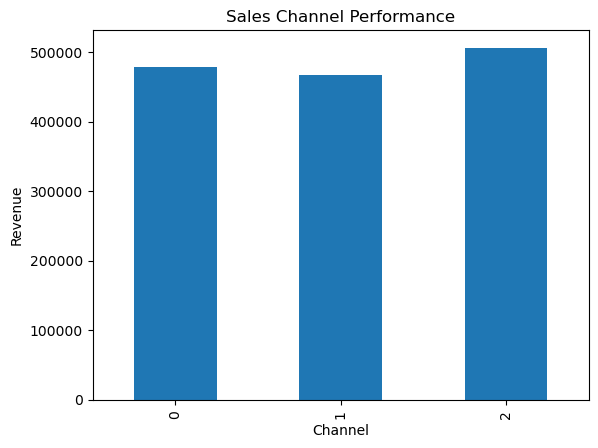

In [7]:
channel_sales = df.groupby('Sales_Channel')['Revenue_USD'].sum()

print("===== CHANNEL PERFORMANCE =====")
print(channel_sales)

channel_sales.plot(kind='bar')
plt.title("Sales Channel Performance")
plt.xlabel("Channel")
plt.ylabel("Revenue")

plt.savefig("channel_performance.png")

plt.show()

### Country-wise Demand Clustering

C:\Users\avnis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


===== CLUSTER OUTPUT =====
   Units_Sold  Revenue_USD  Cluster
0           4       449.60        0
1           4       956.64        0
2           2       382.08        0
3           1       161.70        0
4          14       900.48        0


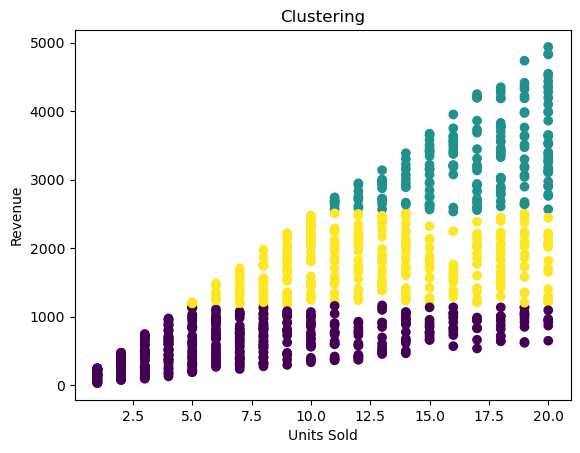

In [8]:
from sklearn.cluster import KMeans

X = df[['Units_Sold','Revenue_USD']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

print("===== CLUSTER OUTPUT =====")
print(df[['Units_Sold','Revenue_USD','Cluster']].head())

# Visualization
plt.scatter(df['Units_Sold'], df['Revenue_USD'], c=df['Cluster'])
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.title("Clustering")

plt.savefig("clustering.png")

plt.show()